In [1]:
import torch
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [2]:
!git clone https://github.com/fashn-AI/fashn-vton-1.5.git
%cd fashn-vton-1.5
!git rev-parse HEAD

Cloning into 'fashn-vton-1.5'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 20), reused 13 (delta 13), pack-reused 67 (from 1)
Receiving objects: 100% (92/92), 334.44 KiB | 27.87 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/kaggle/working/fashn-vton-1.5
7c0f10af3f91ad4048fe9729c470a13ef905d25a


In [3]:
!pip install -q -e .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 9.3 MB/s eta 0:00:00:00:0100:01
  Building editable for fashn-vton (pyproject.toml) ... done


In [4]:
import torch
import fashn_vton

print("FASHN VTON import: OK")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "None"
)

ModuleNotFoundError: No module named 'fashn_vton'

In [5]:
import os
import sys

print("Current directory:", os.getcwd())
print("Repo exists:", os.path.exists("/kaggle/working/fashn-vton-1.5"))
print("src exists:", os.path.exists("/kaggle/working/fashn-vton-1.5/src"))
print(sys.path[:5])

Current directory: /kaggle/working/fashn-vton-1.5
Repo exists: True
src exists: True
['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [6]:
import sys

sys.path.insert(
    0,
    "/kaggle/working/fashn-vton-1.5/src"
)

from fashn_vton import TryOnPipeline

print("FASHN VTON import: OK")

FASHN VTON import: OK


In [7]:
from huggingface_hub import snapshot_download

model_dir = snapshot_download(
    repo_id="fashn-ai/fashn-vton-1.5",
    local_dir="/kaggle/working/fashn-vton-model",
    local_dir_use_symlinks=False
)

print("Model downloaded to:", model_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Model downloaded to: /kaggle/working/fashn-vton-model


In [8]:
import os

print(os.listdir("/kaggle/working/fashn-vton-model")[:20])

['README.md', '.cache', 'model.safetensors', '.gitattributes']


In [9]:
%cd /kaggle/working/fashn-vton-1.5

!python scripts/download_weights.py \
    --weights-dir /kaggle/working/fashn-vton-model

/kaggle/working/fashn-vton-1.5


  Saved to: /kaggle/working/fashn-vton-model/model.safetensors

yolox_l.onnx: 100%|███████████████████████████| 217M/217M [00:01<00:00, 119MB/s]
  Saved to: /kaggle/working/fashn-vton-model/dwpose/yolox_l.onnx
dw-ll_ucoco_384.onnx: 100%|██████████████████| 134M/134M [00:01<00:00, 95.2MB/s]
  Saved to: /kaggle/working/fashn-vton-model/dwpose/dw-ll_ucoco_384.onnx

config.json: 1.65kB [00:00, 4.22MB/s]
model.safetensors: 100%|█████████████████████| 256M/256M [00:04<00:00, 58.1MB/s]
Loading weights: 100%|█| 930/930 [00:00<00:00, 1646.20it/s, Materializing param=
  Cached in HuggingFace hub cache

Download complete!

Weights directory structure:
    /kaggle/working/fashn-vton-model/
    ├── model.safetensors
    └── dwpose/
        ├── yolox_l.onnx
        └── dw-ll_ucoco_384.onnx

Usage:
    from fashn_vton import TryOnPipeline
    pipeline = TryOnPipeline(weights_dir="/kaggle/working/fashn-vton-model")



In [10]:
import os

base = "/kaggle/working/fashn-vton-model"

for path in [
    "model.safetensors",
    "dwpose/yolox_l.onnx",
    "dwpose/dw-ll_ucoco_384.onnx",
]:
    full = os.path.join(base, path)
    print(path, "->", os.path.exists(full))

model.safetensors -> True
dwpose/yolox_l.onnx -> True
dwpose/dw-ll_ucoco_384.onnx -> True


In [11]:
import sys
import torch

sys.path.insert(0, "/kaggle/working/fashn-vton-1.5/src")

from fashn_vton import TryOnPipeline

weights_dir = "/kaggle/working/fashn-vton-model"

pipeline = TryOnPipeline(
    weights_dir=weights_dir,
    device="cuda"
)

print("Pipeline initialized successfully")
print("Device:", pipeline.device)
print("Inference dtype:", pipeline.inference_dtype)

TryOnPipeline - INFO - Using device: cuda
TryOnPipeline - INFO - Using dtype: torch.bfloat16
TryOnPipeline - INFO - Loading TryOnModel from /kaggle/working/fashn-vton-model/model.safetensors
TryOnPipeline - INFO - TryOnModel loaded
TryOnPipeline - INFO - Loading DWPose from /kaggle/working/fashn-vton-model/dwpose
2026-09-01 09:11:17.584817149 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-09-01 09:11:17.586434155 [E:onnxruntime:Default, provider_bridge_ort.cc:2395 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1988 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /usr/local/lib/python3.12/dist-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.13: cannot open shared object file: No such file or directory

2026-09-01 09:11:17.586452276 [W:o

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

TryOnPipeline - INFO - FashnHumanParser loaded


Pipeline initialized successfully
Device: cuda
Inference dtype: torch.bfloat16


In [14]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=True
)

display(uploader)

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload', multiple=True)

In [16]:
from pathlib import Path

upload_dir = Path("/kaggle/working/vton_inputs")
upload_dir.mkdir(parents=True, exist_ok=True)

file_info = uploader.value[0]

output_path = upload_dir / file_info["name"]

with open(output_path, "wb") as f:
    f.write(file_info["content"])

print("Saved:", output_path)

Saved: /kaggle/working/vton_inputs/blue_tshirt_converted.jpg


In [17]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=True
)

display(uploader)

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload', multiple=True)

In [18]:
from pathlib import Path

upload_dir = Path("/kaggle/working/vton_inputs")
upload_dir.mkdir(parents=True, exist_ok=True)

file_info = uploader.value[0]

output_path = upload_dir / file_info["name"]

with open(output_path, "wb") as f:
    f.write(file_info["content"])

print("Saved:", output_path)

Saved: /kaggle/working/vton_inputs/darkbackground.jpg


In [19]:
import os

print(os.listdir("/kaggle/working/vton_inputs"))

['darkbackground.jpg', 'blue_tshirt_converted.jpg']


In [20]:
from PIL import Image
import time

person_path = "/kaggle/working/vton_inputs/darkbackground.jpg"
garment_path = "/kaggle/working/vton_inputs/blue_tshirt_converted.jpg"

person = Image.open(person_path).convert("RGB")
garment = Image.open(garment_path).convert("RGB")

start = time.time()

result = pipeline(
    person_image=person,
    garment_image=garment,
    category="tops"
)

elapsed = time.time() - start

output_path = "/kaggle/working/vton_inputs/fashn_tryon_result.png"
result.images[0].save(output_path)

print("Inference completed")
print("Time:", round(elapsed, 2), "seconds")
print("Saved:", output_path)

TryOnPipeline - INFO - Running inference with 30 timesteps...


Sampling:   0%|          | 0/30 [00:00<?, ?it/s]

TryOnPipeline - INFO - Generated 1 images


Inference completed
Time: 445.38 seconds
Saved: /kaggle/working/vton_inputs/fashn_tryon_result.png


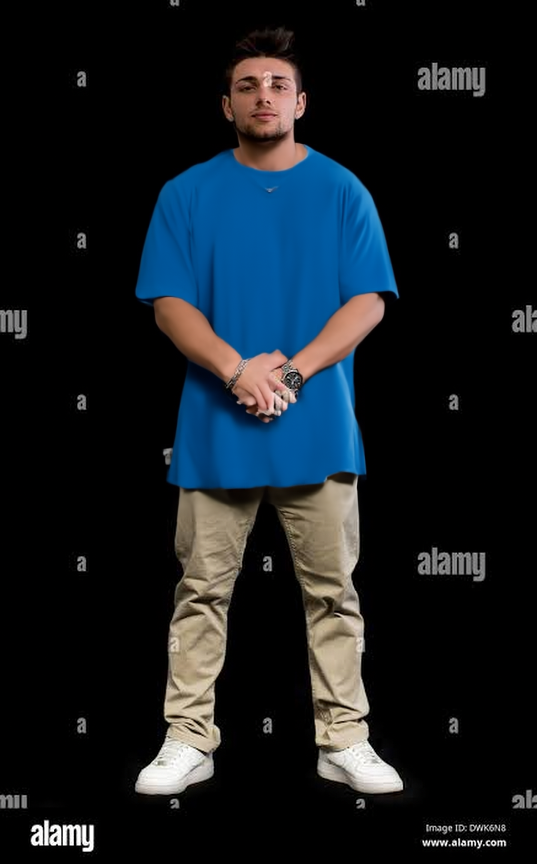

In [21]:
from IPython.display import display

display(result.images[0])

In [22]:
from IPython.display import FileLink

FileLink(
    "/kaggle/working/vton_inputs/fashn_tryon_result.png"
)

/kaggle/working/vton_inputs/fashn_tryon_result.png

In [23]:
import os

path = "/kaggle/working/vton_inputs/fashn_tryon_result.png"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path) if os.path.exists(path) else 0)

Exists: True
Size: 278514


In [24]:
import shutil

shutil.copy(
    "/kaggle/working/vton_inputs/fashn_tryon_result.png",
    "/kaggle/working/fashn_tryon_result.png"
)

print("Copied to /kaggle/working/fashn_tryon_result.png")

Copied to /kaggle/working/fashn_tryon_result.png
